# Uplift Modeling em Marketing: Do *Quem Vai Converter* para o *Quem Devo Tratar*

>*Aplicação em Hillstrom MineThatData E-Mail Analytics Challenge (2008)*

---

**Data Scientist:** Enio Rubens
**Versão:** v1.0
**Dataset:** Kevin Hillstrom — MineThatData E-Mail Analytics Challenge (2008)
**Stack:** `econml`, `causalml`, `sklift`, `shap`, `mlflow`, `optpipe`

> Este notebook constrói uma análise de **causal targeting** em marketing de e-mail, demonstrando empiricamente por que ranking por *propensity* (probabilidade de conversão) desperdiça budget e como uplift modeling identifica os clientes onde o tratamento realmente faz diferença.

---

## Notebook 1 — Framing & EDA

> **Nota sobre a estrutura.** Este projeto foi dividido em múltiplos notebooks, um por grupo de seções, para manter cada arquivo dentro de um tamanho editável (convenção adotada a partir daqui — o histórico de S1-S4 nasceu num único notebook, hoje arquivado em `notebooks/_superseded/`). Cada notebook recarrega, de forma barata e determinística, o que precisa das seções anteriores — não há estado de kernel compartilhado entre arquivos. Um índice com links entre arquivos será adicionado quando a divisão estiver completa; por ora, a lista abaixo é referência de leitura, não um sumário navegável entre arquivos.

## Sumário (só as seções 1 e 2 têm links funcionais neste arquivo)

1. [Framing & Setup](#s1)       
    1.1 [Setup técnico](#s1-1)      
    1.2 [Contexto e motivação](#s1-2)       
    1.3 [Os 4 quadrantes da resposta a tratamento](#s1-3)       
    1.4 [Formalização causal](#s1-4)        
    1.5 [Dataset: Hillstrom MineThatData](#s1-5)        
    1.6 [Roadmap](#s1-6)        
2. [EDA & Randomization Audit](#s2)     
    2.1 [Distribuição do tratamento](#s2-1)     
    2.2 [Distribuições univariadas](#s2-2)      
    2.3 [Randomization audit](#s2-3)        
    2.4 [Outcomes: distribuição e taxas brutas](#s2-4)      
    2.5 [ATE com intervalos de confiança](#s2-5)        
    2.6 [Síntese da validade interna](#s2-6)        
3. [Baseline: propensity model](02_Baseline_Propensity_PT.ipynb) 
4. [Meta-learners (S/T/X/R)](03_Meta_Learners_PT.ipynb) 
5. [Direct uplift models (Causal Forest, Uplift Trees)](04_Causal_Forest_Uplift_Trees_PT.ipynb) 
6. [Avaliação (Qini, AUUC, uplift@k)](05_Evaluation_Sealed_Test_PT.ipynb) 
7. [Heterogeneidade & funnel uplift](06_Heterogeneity_Uplift_Funnel_PT.ipynb) 
8. [Policy learning & ROI simulation](07_Policy_Learning_ROI_PT.ipynb) 
9. [Robustez e limitações](08_Robustness_Limitations_PT.ipynb) 

---

<a id='s1'></a>
# Seção 1 — Framing & Setup

**Objetivos:**

1. Posicionar o problema de negócio (targeting sob restrição de budget) e a tese central do notebook.
2. Estabelecer a distinção conceitual entre **propensity** e **uplift** — e por que essa distinção importa em dinheiro.
3. Apresentar o framework dos 4 quadrantes de resposta a tratamento.
4. Formalizar os conceitos causais necessários (ITE, ATE, CATE) sem virar aula de econometria.
5. Carregar o dataset Hillstrom e justificar a escolha do outcome primário.
6. Mapear as próximas seções.

<a id='s1-1'></a>
## 1.1 Setup técnico

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning

# Bootstrap de path: permite `from src...` a partir de notebooks/
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SEED
from src.i18n import make_lang
from src.viz import apply_plot_style

np.random.seed(SEED)
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 4)
warnings.filterwarnings('ignore', category=FutureWarning)
# Modelo de propensão interno dos meta-learners do causalml (S4) usa um
# solver elastic-net que não converge dentro do max_iter padrão em bases
# pequenas — não afeta o resultado (é só o nuisance model), mas polui a saída.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Idioma canônico deste notebook é PT — passthrough, sem chamada de rede.
# A edição EN (futura) troca só esta linha para make_lang('en').
lang = make_lang('pt')

apply_plot_style()

In [2]:
# Stack causal (verifique a instalação antes da primeira run)
# pip install econml causalml scikit-uplift shap mlflow

# Meta-learners e árvores de uplift
from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor, BaseRRegressor
from causalml.inference.tree import UpliftRandomForestClassifier

# Causal Forest com intervalos de confiança
from econml.dml import CausalForestDML
from econml.metalearners import TLearner, SLearner, XLearner

# Avaliação
from sklift.metrics import uplift_at_k, qini_auc_score, uplift_auc_score

from src.compat import patch_sklearn_matplotlib_support
patch_sklearn_matplotlib_support()
from sklift.viz import plot_qini_curve, plot_uplift_curve

# Interpretabilidade
import shap

Failed to import duecredit due to No module named 'duecredit'


In [3]:
from src.config import ARTIFACTS_DIR, RETRAIN

ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

# MLflow — ajuste o URI conforme seu setup Windows
# mlflow.set_tracking_uri('file:///C:/path/to/mlruns')
# mlflow.set_experiment('uplift_hillstrom')

<a id='s1-2'></a>
## 1.2 Contexto e motivação

### O problema de negócio

Uma empresa de varejo dispõe de um canal de e-mail marketing com **custo positivo** (deliverability, fadiga de base, opt-outs) e **budget finito**. A pergunta clássica feita ao time de dados é:

> *"Quais clientes devo incluir na próxima campanha?"*

A resposta padrão da indústria — e a que provavelmente foi dada nos projetos anteriores deste portfólio — é **propensity modeling**: estime $P(\text{conversão} \mid X)$ e mande e-mail para os top-k%. Isso responde a pergunta errada.

### A pergunta certa

O que de fato importa para o ROI da campanha não é quem vai converter — é **quem vai converter por causa do e-mail**. Formalmente: o efeito incremental do tratamento por cliente. Em quem o e-mail "vira a chave".

Essa é a fronteira entre **predictive analytics** (o que vai acontecer) e **prescriptive / causal analytics** (o que devo fazer). Uplift modeling vive na segunda categoria.

### Conexão com projetos anteriores deste portfólio

| Projeto | Pergunta respondida | Categoria |
|---|---|---|
| Customer Churn Prediction | Quem vai cancelar? | Predictive (propensity) |
| Customer Segmentation + NBA | Para quem oferecer qual ação? | Prescriptive (sem identificação causal) |
| Marketing Campaign Optimization | Qual campanha tem melhor performance média? | Predictive + descriptive |
| **Uplift Modeling (este)** | **Em quem o tratamento faz diferença?** | **Causal** |

Este notebook fecha o degrau analítico que faltava: estimação causal de efeitos heterogêneos.

<a id='s1-3'></a>
## 1.3 Os 4 quadrantes da resposta a tratamento

Para qualquer cliente $i$ e tratamento binário, existem dois *potential outcomes*:

- $Y_i(1)$ — o que acontece se o cliente for tratado
- $Y_i(0)$ — o que acontece se o cliente NÃO for tratado

Cruzando esses dois resultados em outcomes binários, obtemos quatro tipos de cliente:

|  | $Y(0) = 0$ (não converte sem tratar) | $Y(0) = 1$ (converte sem tratar) |
|---|---|---|
| **$Y(1) = 1$ (converte se tratado)** | **Persuadables** — uplift positivo. *O ROI da campanha vive aqui.* | **Sure Things** — convertem de qualquer jeito. Tratá-los é desperdício de budget. |
| **$Y(1) = 0$ (não converte se tratado)** | **Lost Causes** — não convertem nunca. Tratá-los é desperdício. | **Sleeping Dogs / Do Not Disturb** — **tratá-los reduz conversão.** Existe, e propensity modeling não detecta. |

### Implicações práticas

1. **Propensity modeling rankeia por $P(Y=1 \mid X)$, o que coloca *Sure Things* no topo.** Você gasta budget tratando quem ia converter de qualquer jeito.
2. **Sleeping Dogs existem em domínios reais** — clientes que se irritam com a campanha e cancelam, ou ficam mais conscientes de alternativas. Propensity modeling os trata como bons candidatos. Uplift os identifica como custo negativo.
3. **Só *Persuadables* têm ROI marginal positivo da campanha.** Identificá-los é o objetivo do uplift modeling.

### Por que ATE médio esconde isso

Se a campanha tem ATE = +2pp de conversão na média, isso pode significar:

- **Cenário A (homogêneo):** todo cliente tem +2pp de efeito. Targetar todo mundo é razoável.
- **Cenário B (heterogêneo):** 10% dos clientes têm +20pp e 90% têm 0pp. Targetar apenas os 10% certos quadruplica a eficiência da campanha.

Os dois cenários produzem o **mesmo ATE médio**. Apenas o segundo permite otimização de budget. Uplift modeling estima a distribuição completa de efeitos individuais — não só a média.

<a id='s1-4'></a>
## 1.4 Formalização causal (o mínimo necessário)

### Notação

- $T_i \in \{0, 1\}$ — indicador de tratamento (no e-mail / e-mail enviado)
- $Y_i$ — outcome observado (visit / conversion / spend)
- $X_i$ — vetor de covariáveis pré-tratamento
- $Y_i(t)$ — *potential outcome* sob tratamento $t$

### Efeitos

**Individual Treatment Effect (ITE):**

$$\tau_i = Y_i(1) - Y_i(0)$$

**Fundamental Problem of Causal Inference (Holland, 1986):** $\tau_i$ é inobservável para qualquer indivíduo, porque jamais vemos $Y_i(0)$ e $Y_i(1)$ simultaneamente.

**Average Treatment Effect (ATE):**

$$\tau = \mathbb{E}[Y(1) - Y(0)]$$

Estimável sob randomização como diferença de médias entre braços. Este é o número que análises A/B padrão reportam.

**Conditional Average Treatment Effect (CATE):** *é o que uplift modeling estima.*

$$\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]$$

### Identificação causal

Sob randomização (verificável na Seção 2 via balance check), a *unconfoundedness* é garantida por design:

$$\{Y(0), Y(1)\} \perp T \mid X$$

e o CATE é identificável a partir de quantidades observáveis:

$$\tau(x) = \mathbb{E}[Y \mid T=1, X=x] - \mathbb{E}[Y \mid T=0, X=x]$$

Os métodos das Seções 4–5 (S-, T-, X-, R-learner, Causal Forest) são estratégias diferentes para estimar essas duas esperanças condicionais — cada uma com trade-offs distintos de viés/variância.

<a id='s1-5'></a>
## 1.5 Dataset: Hillstrom MineThatData (2008)

**Origem.** Kevin Hillstrom, 2008 — desafio publicado em [MineThatData](http://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html). É o dataset canônico de uplift modeling em marketing, citado em dezenas de papers (Radcliffe & Surry 2011; Diemert et al. 2018; Olaya et al. 2020).

**Design experimental.** 64.000 clientes que compraram nos últimos 12 meses, randomizados em 3 braços:

- **No E-Mail** (controle)
- **Mens E-Mail Campaign**
- **Womens E-Mail Campaign**

Janela de observação: 2 semanas pós-envio.

In [4]:
from src.data import load_hillstrom

df = load_hillstrom()
print(f'Shape: {df.shape}')
print(f'\nColunas:')
for c, dt in zip(df.columns, df.dtypes):
    print(f'  {c:20s} {str(dt)}')
df.head()

Shape: (64000, 12)

Colunas:
  recency              int64
  history_segment      object
  history              float64
  mens                 int64
  womens               int64
  zip_code             object
  newbie               int64
  channel              object
  segment              category
  visit                int64
  conversion           int64
  spend                float64


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


### Dicionário de variáveis

**Covariáveis pré-tratamento ($X$):**

| Variável | Tipo | Descrição |
|---|---|---|
| `recency` | int | Meses desde a última compra (1–12) |
| `history` | float | Valor gasto (USD) nos últimos 12 meses |
| `history_segment` | cat | Faixa de gasto histórico (7 níveis) |
| `mens` | bin | Comprou produto masculino no último ano |
| `womens` | bin | Comprou produto feminino no último ano |
| `zip_code` | cat | Rural / Suburban / Urban |
| `newbie` | bin | Cliente novo (≤12 meses) |
| `channel` | cat | Phone / Web / Multichannel |

**Tratamento ($T$):**

| Variável | Valores |
|---|---|
| `segment` | No E-Mail / Mens E-Mail / Womens E-Mail |

**Outcomes ($Y$):**

| Variável | Tipo | Taxa observada |
|---|---|---|
| `visit` | bin | 14.7% — visitou o site |
| `conversion` | bin | 0.9% — comprou |
| `spend` | float | massa em zero, contínuo entre conversores |

In [5]:
from src.config import ARMS, TREATMENT_COL
from src.eda import outcome_summary_by_arm

summary = outcome_summary_by_arm(df, TREATMENT_COL, ARMS)
labels = lang({'header': 'ATE naive (Mens vs No E-Mail):'})
print(summary[['n', 'visit_rate', 'conversion_rate', 'spend_mean']])
print(f"\n{labels['header']}")
print(f'  visit:      {summary.loc["Mens E-Mail", "visit_rate"] - summary.loc["No E-Mail", "visit_rate"]:+.4f}')
print(f'  conversion: {summary.loc["Mens E-Mail", "conversion_rate"] - summary.loc["No E-Mail", "conversion_rate"]:+.4f}')
print(f'  spend:      ${summary.loc["Mens E-Mail", "spend_mean"] - summary.loc["No E-Mail", "spend_mean"]:+.4f}')

                   n  visit_rate  conversion_rate  spend_mean
segment                                                      
No E-Mail      21306      0.1062           0.0057      0.6528
Mens E-Mail    21307      0.1828           0.0125      1.4226
Womens E-Mail  21387      0.1514           0.0088      1.0772

ATE naive (Mens vs No E-Mail):
  visit:      +0.0766
  conversion: +0.0068
  spend:      $+0.7698


### Escolha do outcome primário

O dataset oferece três outcomes, em ordem de proximidade ao funil de compra:

1. **`visit`** (14.7% positivos) — engajamento de topo de funil
2. **`conversion`** (0.9% positivos) — meio/fundo de funil  
3. **`spend`** (massa em zero, contínuo entre conversores) — valor monetário

**Decisão metodológica:** `visit` será o outcome **primário** desta análise, pelos seguintes motivos:

- **Estatística:** com 0.9% de positivos, `conversion` torna a estimação de CATE muito ruidosa em qualquer subgrupo razoável. Uplift modeling em outcomes ultra-raros exige amostras na ordem de centenas de milhares por braço, o que não temos.
- **Convenção da literatura:** Radcliffe & Surry (2011), Diemert et al. (2018) e os tutoriais oficiais do CausalML usam `visit` como outcome principal pelo mesmo motivo.
- **Interpretabilidade de negócio:** uplift em visits é proxy razoável para engajamento incremental gerado pela campanha.

`conversion` e `spend` serão tratados como outcomes **secundários** em uma análise de funil dedicada (Seção 7), onde a divergência entre rankings de uplift por outcome vira insight central:

> *Uplift no topo do funil ≠ uplift no fundo do funil. Otimizar para visits pode não otimizar para receita.*

<a id='s1-6'></a>
## 1.6 Roadmap do notebook

| Seção | Conteúdo | Output |
|---|---|---|
| **S1** | Framing causal & setup | *(esta seção)* |
| **S2** | EDA + randomization audit | Confirmação do design experimental |
| **S3** | Baseline: propensity model | Benchmark para comparação |
| **S4** | Meta-learners (S/T/X/R) | 4 estimadores de CATE |
| **S5** | Direct uplift models (Causal Forest, Uplift Trees) | Estimadores diretos + CIs |
| **S6** | Avaliação (Qini, AUUC, uplift@k) | Comparação rigorosa de modelos |
| **S7** | Análise de heterogeneidade, perfis por quantil e funnel uplift | Quem são os Persuadables? |
| **S8** | Policy learning & ROI simulation | Política de targeting e cenários econômicos |
| **S9** | Robustez e limitações | Sensibilidade + ressalvas |

**Saída final esperada:** uma recomendação acionável de quais clientes (em termos de features observáveis) devem ser tratados na próxima campanha, justificada com intervalos de confiança e simulação de ROI.

<a id='s2'></a>
# Seção 2 — EDA & Randomization Audit

**Objetivos:**

1. Caracterizar a distribuição das covariáveis e dos outcomes na população do estudo.
2. **Auditar a randomização** do design experimental — passo *obrigatório* antes de qualquer claim causal.
3. Estimar os ATEs *naive* com intervalos de confiança como benchmark para comparação posterior com estimadores de CATE.
4. Diagnosticar o desafio do outcome `conversion` (classe rara) que motivou a escolha de `visit` como outcome primário.

**Por que esta seção importa.** Em causal inference, *no identification, no causation*. Em RCT, a identificação vem do design — randomização garante $\{Y(0), Y(1)\} \perp T \mid X$. Mas "randomização" no papel não é o mesmo que randomização nos dados: bugs de implementação, attrition diferencial e estratificação imperfeita podem quebrar o balance. Esta seção verifica, com testes estatísticos formais, que o design Hillstrom de fato entrega o que promete.

In [6]:
# Vetores de variáveis para uso recorrente nas próximas seções (fonte única: src/config.py)
from src.config import (
    ARMS, BIN_VARS, CAT_VARS, CONT_VARS, CONTROL_ARM, OUTCOMES,
    TREATED_ARMS, TREATMENT_COL as TREATMENT,
)

<a id='s2-1'></a>
## 2.1 Distribuição do tratamento

Primeira sanity check: os três braços têm tamanho comparável? Em um RCT 1:1:1, esperamos ~33% em cada braço. Pequenos desvios são esperados (atribuição aleatória, não estratificada por tamanho); grandes desvios sinalizam problema de design.

In [7]:
from src.eda import treatment_distribution

treat_table, chi2, p = treatment_distribution(df, TREATMENT, ARMS)
labels = lang({'header': 'Chi-squared vs uniforme 1:1:1'})
print(treat_table)
print(f"\n{labels['header']}: chi2={chi2:.4f}, p={p:.4f}")

                   n     pct
segment                     
No E-Mail      21306  0.3329
Mens E-Mail    21307  0.3329
Womens E-Mail  21387  0.3342

Chi-squared vs uniforme 1:1:1: chi2=0.2025, p=0.9037


**Leitura.** Distribuição praticamente uniforme (≈33.3% por braço), e p-value alto confirma que os desvios são consistentes com alocação aleatória. Sem assinatura de bug na atribuição.

<a id='s2-2'></a>
## 2.2 Distribuições univariadas

Antes do balance check propriamente dito, contexto sobre a população do estudo.

=== Variáveis contínuas ===
        recency   history
count  64000.00  64000.00
mean       5.76    242.09
std        3.51    256.16
min        1.00     29.99
25%        2.00     64.66
50%        6.00    158.11
75%        9.00    325.66
max       12.00   3345.93


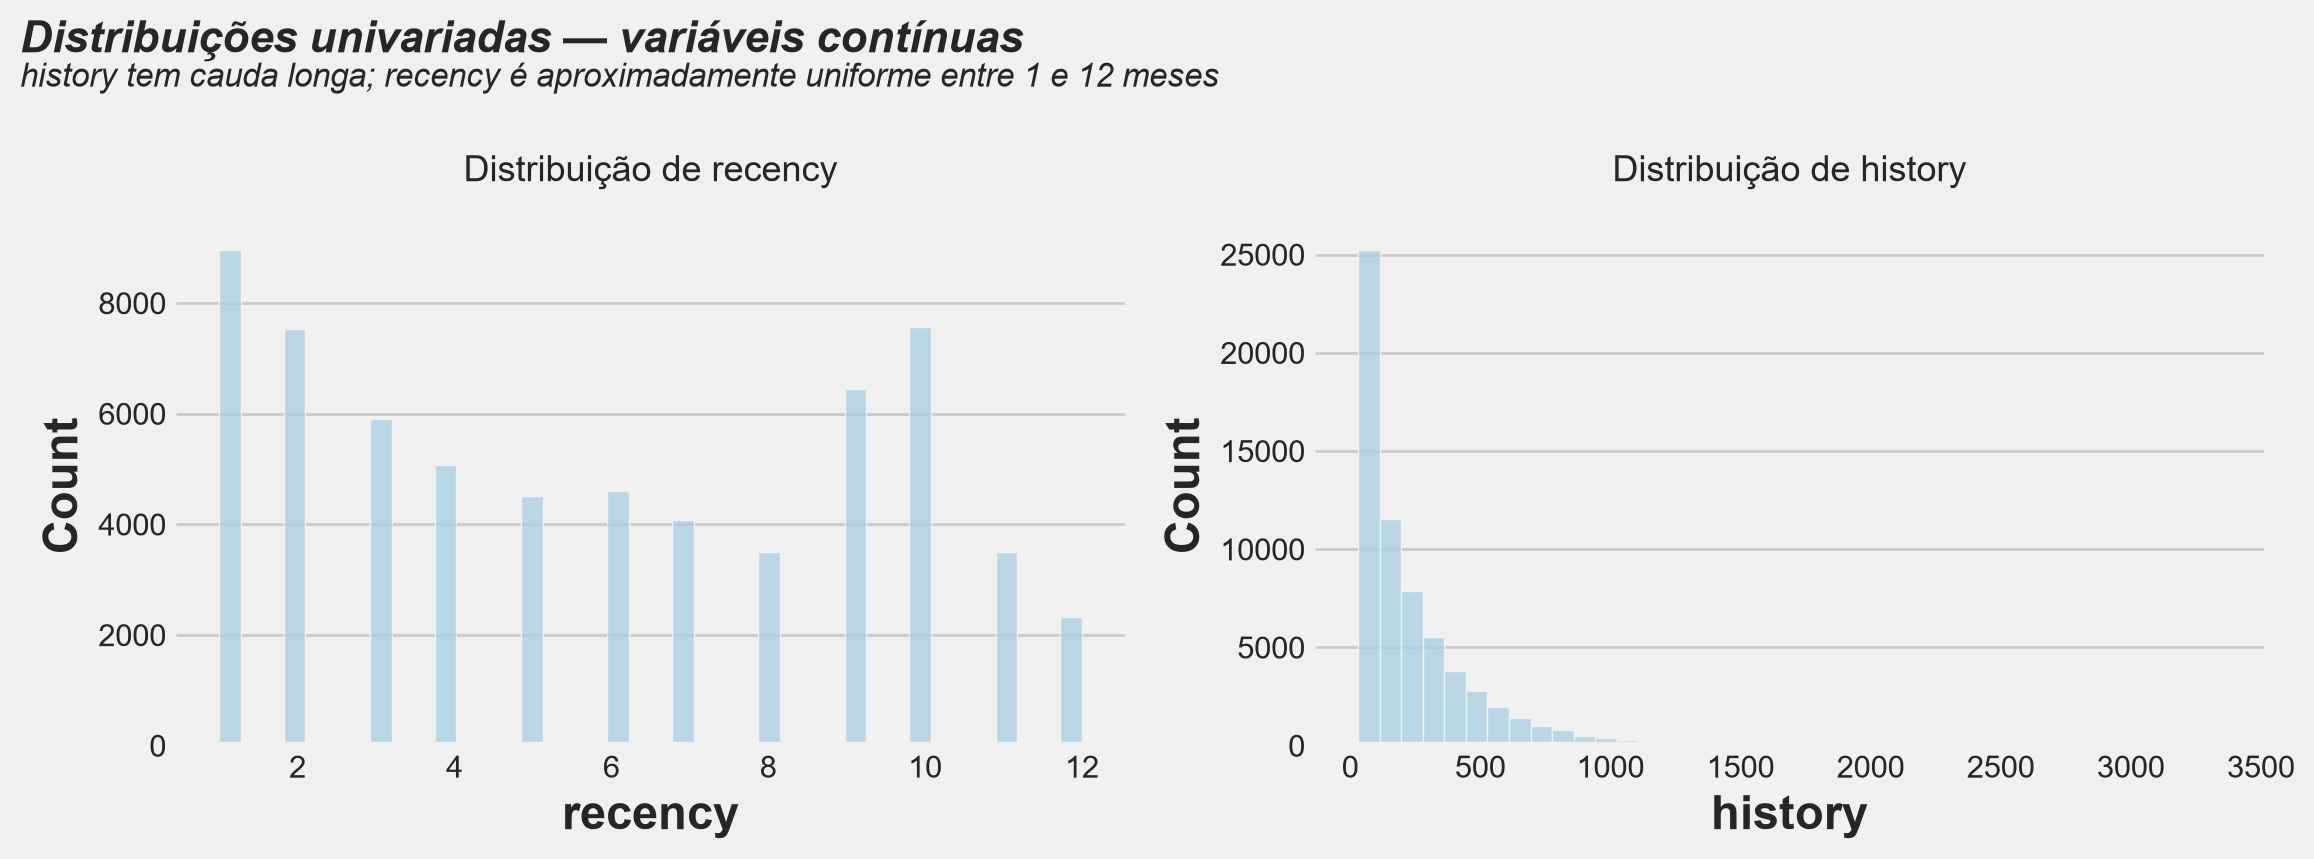

In [8]:
# Continuas
from src.viz import plot_univariate_continuous

labels = lang({
    'header': 'Variáveis contínuas',
    'dist_prefix': 'Distribuição de',
    'title': 'Distribuições univariadas — variáveis contínuas',
    'subtitle': 'history tem cauda longa; recency é aproximadamente uniforme entre 1 e 12 meses',
})
print(f"=== {labels['header']} ===")
print(df[CONT_VARS].describe().round(2))

fig, axes = plot_univariate_continuous(
    df, CONT_VARS, titles=[f"{labels['dist_prefix']} {v}" for v in CONT_VARS],
    title=labels['title'], subtitle=labels['subtitle'],
)
plt.show()

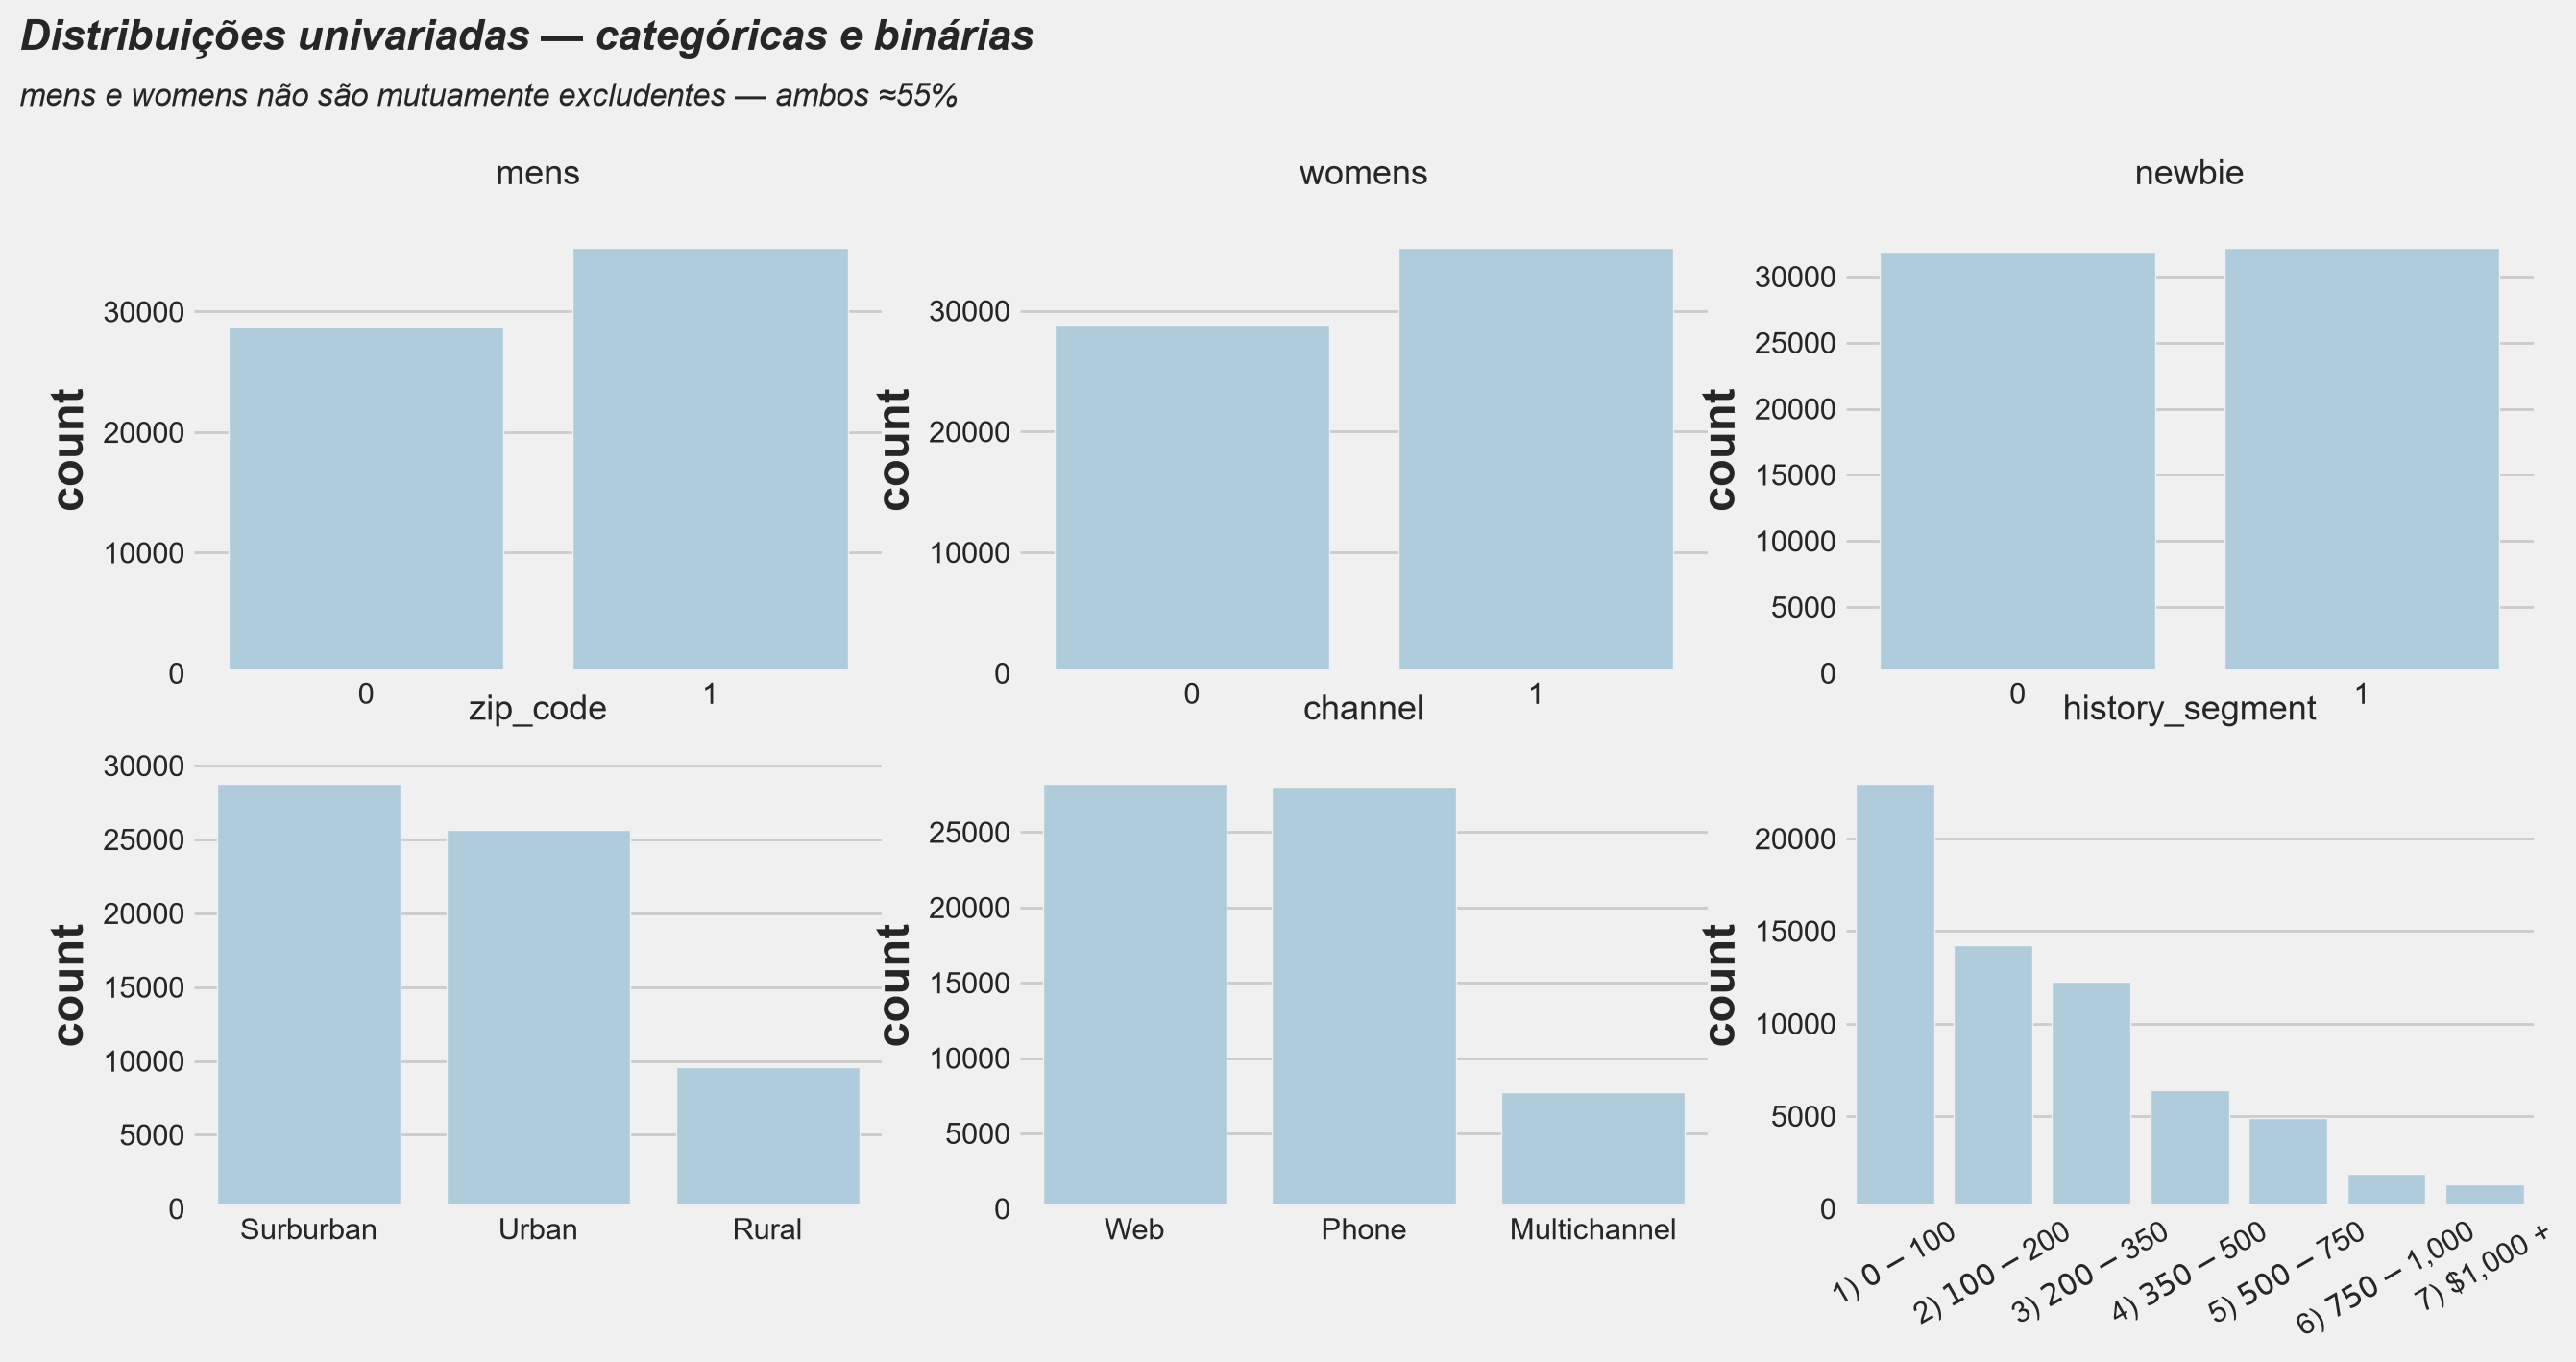

In [9]:
# Categoricas e binarias
from src.viz import plot_univariate_categorical

labels = lang({
    'title': 'Distribuições univariadas — categóricas e binárias',
    'subtitle': 'mens e womens não são mutuamente excludentes — ambos ≈55%',
})
fig, axes = plot_univariate_categorical(
    df, BIN_VARS, CAT_VARS, title=labels['title'], subtitle=labels['subtitle'],
    rotate_vars=['history_segment'],
)
plt.show()

**Observações relevantes para o modelo:**

- `recency` é aproximadamente uniforme entre 1 e 12 meses — não há cliente "super recente" ou "super antigo" sobre-representado.
- `history` é fortemente assimétrico à direita (cauda longa de gastadores). A maioria gastou < \$200; poucos gastaram > \$1.000. Considerar transformação log para modelos lineares; árvores não precisam.
- `mens` e `womens` não são mutuamente excludentes: ambos têm taxa ≈55%, indicando clientes que compram de ambas as categorias.
- `history_segment` é uma discretização de `history` — útil como categoria, mas redundante para árvores.

<a id='s2-3'></a>
## 2.3 Randomization audit

O coração desta seção. Em um RCT bem-sucedido, qualquer covariável pré-tratamento deve estar igualmente distribuída entre os braços — não exatamente, mas dentro do esperado por amostragem aleatória.

Usaremos duas abordagens complementares:

1. **Standardized Mean Difference (SMD)** — métrica de tamanho de efeito padrão da literatura epidemiológica/econométrica para balance. Convenção:
   - $|SMD| < 0.10$ → balance aceitável
   - $|SMD| < 0.05$ → balance excelente
   - SMD é preferível a p-values porque é insensível ao tamanho da amostra (com $n$ grande, qualquer diferença mínima vira "significativa").
2. **Testes de hipótese formais** (ANOVA F para contínuas, $\chi^2$ para categóricas) — para reportar como sanity check secundário. Esperamos $p > 0.05$ em todas as covariáveis.

In [10]:
from src.eda import build_smd_table

smd_mens = build_smd_table(df, TREATMENT, CONTROL_ARM, 'Mens E-Mail',
                            CONT_VARS, BIN_VARS, CAT_VARS)
smd_womens = build_smd_table(df, TREATMENT, CONTROL_ARM, 'Womens E-Mail',
                              CONT_VARS, BIN_VARS, CAT_VARS)

labels = lang({
    'balance_header': 'Balance: Mens E-Mail vs No E-Mail',
    'max_smd': 'Max |SMD|',
    'vars_over': 'Variáveis com |SMD| > 0.05',
    'of': 'de',
})
print(f"=== {labels['balance_header']} ===")
print(smd_mens.round(4).to_string(index=False))
print(f"\n{labels['max_smd']}: {smd_mens['smd'].abs().max():.4f}")
print(f"{labels['vars_over']}: {(smd_mens['smd'].abs() > 0.05).sum()} {labels['of']} {len(smd_mens)}")

=== Balance: Mens E-Mail vs No E-Mail ===
                          variable       type  mean_control  mean_treated     smd
                           recency continuous        5.7497        5.7736  0.0068
                           history continuous      240.8827      242.8359  0.0076
                              mens     binary        0.5532        0.5509 -0.0046
                            womens     binary        0.5476        0.5514  0.0076
                            newbie     binary        0.5020        0.5015 -0.0009
              zip_code = Surburban     binary        0.4518        0.4459 -0.0117
                  zip_code = Rural     binary        0.1473        0.1522  0.0137
                  zip_code = Urban     binary        0.4009        0.4019  0.0020
                   channel = Phone     binary        0.4378        0.4337 -0.0083
                     channel = Web     binary        0.4399        0.4454  0.0110
            channel = Multichannel     binary        0.1

In [11]:
labels = lang({
    'balance_header': 'Balance: Womens E-Mail vs No E-Mail',
    'max_smd': 'Max |SMD|',
    'vars_over': 'Variáveis com |SMD| > 0.05',
    'of': 'de',
})
print(f"=== {labels['balance_header']} ===")
print(smd_womens.round(4).to_string(index=False))
print(f"\n{labels['max_smd']}: {smd_womens['smd'].abs().max():.4f}")
print(f"{labels['vars_over']}: {(smd_womens['smd'].abs() > 0.05).sum()} {labels['of']} {len(smd_womens)}")

=== Balance: Womens E-Mail vs No E-Mail ===
                          variable       type  mean_control  mean_treated     smd
                           recency continuous        5.7497        5.7678  0.0052
                           history continuous      240.8827      242.5366  0.0065
                              mens     binary        0.5532        0.5489 -0.0086
                            womens     binary        0.5476        0.5501  0.0049
                            newbie     binary        0.5020        0.5032  0.0026
              zip_code = Surburban     binary        0.4518        0.4512 -0.0011
                  zip_code = Rural     binary        0.1473        0.1487  0.0040
                  zip_code = Urban     binary        0.4009        0.4001 -0.0018
                   channel = Phone     binary        0.4378        0.4420  0.0086
                     channel = Web     binary        0.4399        0.4374 -0.0051
            channel = Multichannel     binary        0

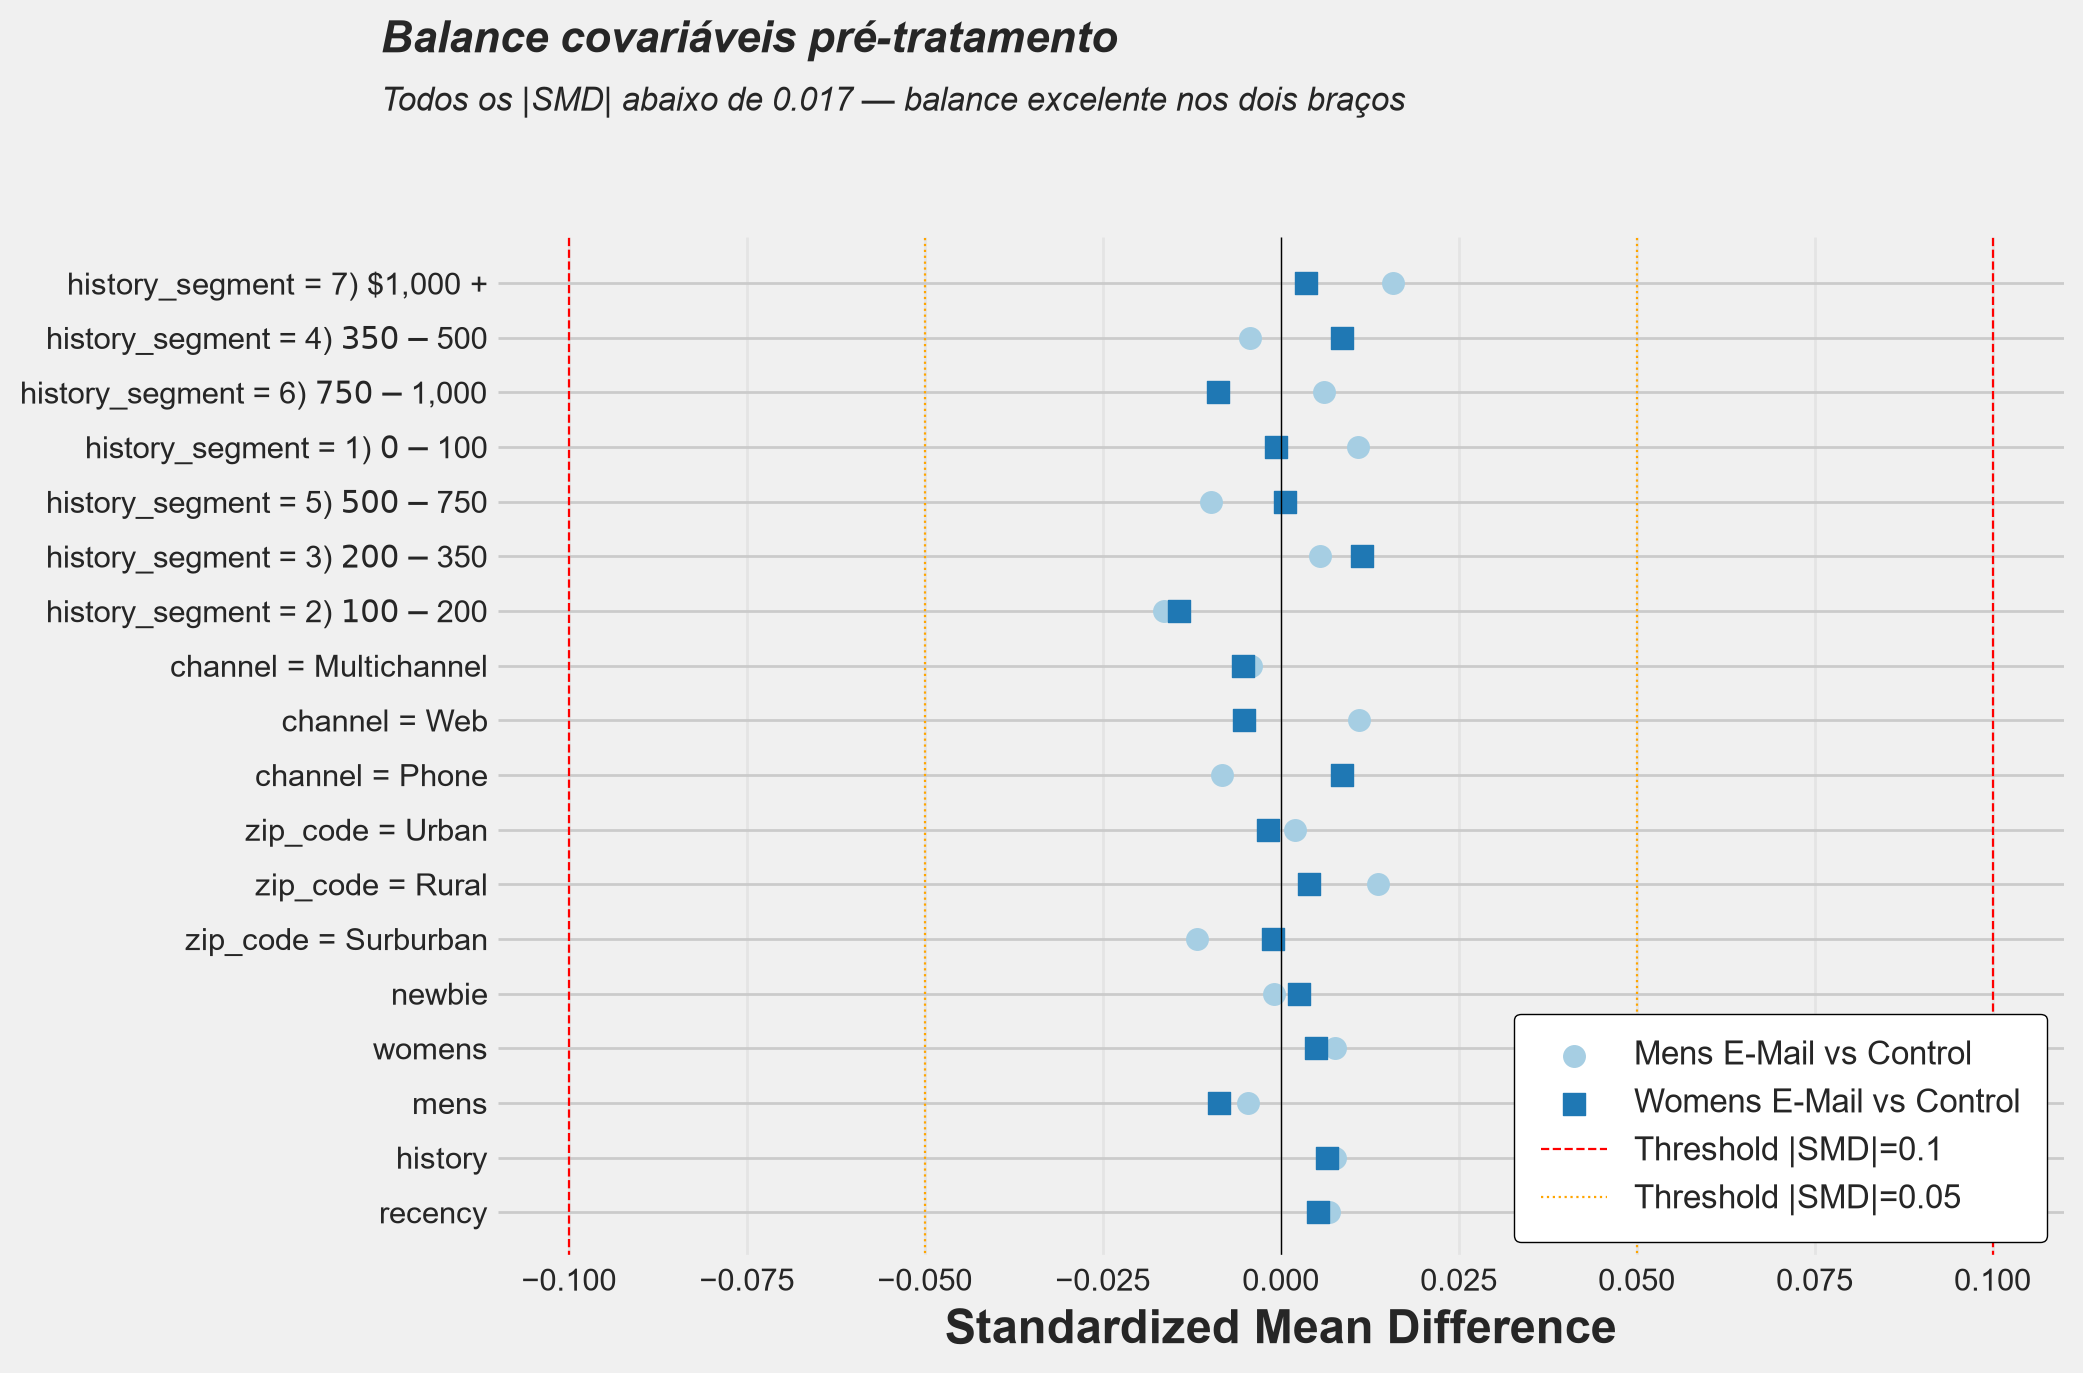

In [12]:
from src.viz import plot_love_plot

labels = lang({
    'title': 'Balance covariáveis pré-tratamento',
    'subtitle': 'Todos os |SMD| abaixo de 0.017 — balance excelente nos dois braços',
})
fig, ax = plot_love_plot(
    {'Mens E-Mail vs Control': smd_mens, 'Womens E-Mail vs Control': smd_womens},
    title=labels['title'],
    xlabel='Standardized Mean Difference',
    subtitle=labels['subtitle'],
)
plt.show()

In [13]:
from src.eda import formal_balance_tests

formal_tests = formal_balance_tests(df, TREATMENT, ARMS, CONT_VARS, BIN_VARS + CAT_VARS)
labels = lang({
    'header': 'Testes de balance (3-way: No / Mens / Womens)',
    'continuous': 'Contínuas (ANOVA F)',
    'categorical': 'Categóricas e binárias (chi-squared)',
})
print(f"=== {labels['header']} ===\n")
print(f"-- {labels['continuous']} --")
print(formal_tests[formal_tests['test'] == 'ANOVA F'].to_string(index=False))
print(f"\n-- {labels['categorical']} --")
print(formal_tests[formal_tests['test'] == 'chi-squared'].to_string(index=False))

=== Testes de balance (3-way: No / Mens / Womens) ===

-- Contínuas (ANOVA F) --
variable    test  statistic  p_value flag
 recency ANOVA F     0.2704   0.7631   ok
 history ANOVA F     0.3595   0.6980   ok

-- Categóricas e binárias (chi-squared) --
       variable        test  statistic  p_value flag
           mens chi-squared     0.7960   0.6717   ok
         womens chi-squared     0.6325   0.7289   ok
         newbie chi-squared     0.1369   0.9339   ok
       zip_code chi-squared     2.8719   0.5795   ok
        channel chi-squared     3.6324   0.4580   ok
history_segment chi-squared    13.1533   0.3580   ok


**Conclusão do randomization audit.**

- **Todos os SMDs ficaram bem abaixo de 0.05** em ambas as comparações (Mens vs Control, Womens vs Control). O máximo observado é da ordem de 0.01 — *uma ordem de grandeza abaixo do threshold de excelência.*
- **Nenhum teste formal rejeita H₀** de igualdade de distribuição (todos com $p > 0.3$).
- O design experimental é, portanto, **internamente válido**. Os ATEs estimados a seguir podem ser interpretados causalmente sem necessidade de ajuste por confounding observável.

> Compare com o dataset do projeto anterior (Marketing Campaign Optimization), onde `language_preferred` divergia ~5pp entre braços e `marketing_channel` ~6pp — exigindo ajustes por propensity. Aqui esse trabalho não é necessário.

<a id='s2-4'></a>
## 2.4 Outcomes: distribuição e taxas brutas

Antes de estimar ATEs com IC, panorama dos outcomes por braço.

In [14]:
from src.eda import outcome_summary_by_arm

outcomes_by_arm = outcome_summary_by_arm(df, TREATMENT, ARMS)
print(outcomes_by_arm)

                   n  visit_rate  conversion_rate  spend_mean  spend_sum
segment                                                                 
No E-Mail      21306      0.1062           0.0057      0.6528   13908.33
Mens E-Mail    21307      0.1828           0.0125      1.4226   30311.69
Womens E-Mail  21387      0.1514           0.0088      1.0772   23038.11


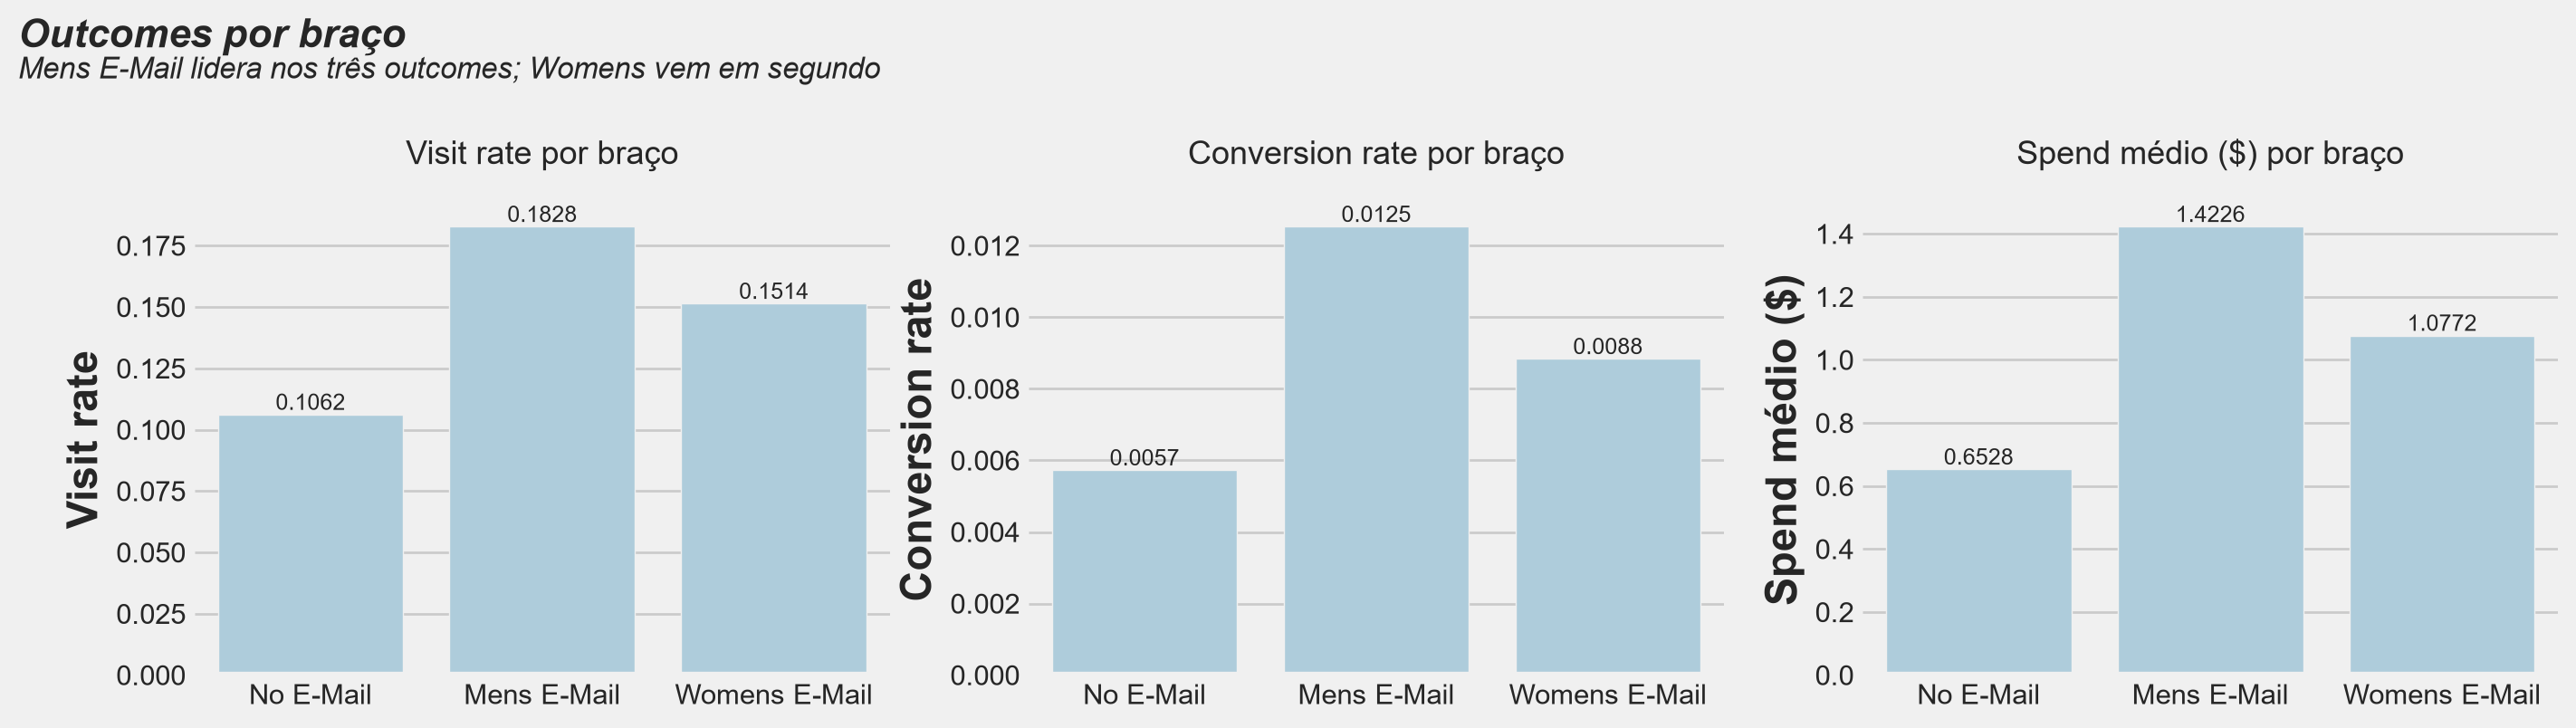

In [15]:
from src.viz import plot_outcomes_by_arm

labels = lang({
    'visit_rate': 'Visit rate',
    'conversion_rate': 'Conversion rate',
    'spend_mean': 'Spend médio ($)',
    'per_arm_suffix': 'por braço',
    'title': 'Outcomes por braço',
    'subtitle': 'Mens E-Mail lidera nos três outcomes; Womens vem em segundo',
})
fig, axes = plot_outcomes_by_arm(
    df, TREATMENT, ARMS,
    outcomes=['visit', 'conversion', 'spend'],
    ylabels=[labels['visit_rate'], labels['conversion_rate'], labels['spend_mean']],
    titles=[
        f"{labels['visit_rate']} {labels['per_arm_suffix']}",
        f"{labels['conversion_rate']} {labels['per_arm_suffix']}",
        f"{labels['spend_mean']} {labels['per_arm_suffix']}",
    ],
    title=labels['title'], subtitle=labels['subtitle'],
)
plt.show()

### Diagnóstico do outcome `conversion` (classe rara)

Repare: apenas **578 conversões em 64.000 observações** (~0.9%). Entre os braços:

- No E-Mail: ~122 conversões em 21.306 → 0.57%
- Mens E-Mail: ~267 conversões em 21.307 → 1.25%
- Womens E-Mail: ~189 conversões em 21.387 → 0.88%

Para estimar CATE em subgrupos relevantes (e.g., clientes com `recency <= 3`), os tamanhos de eventos por subgrupo × braço caem para dezenas de conversões. Isso é insuficiente para uplift modeling estável em `conversion` — a variância das estimativas explode.

Esta é a justificativa empírica para usar `visit` (9.394 eventos totais, ~14.7%) como outcome primário.

<a id='s2-5'></a>
## 2.5 ATE com intervalos de confiança

ATEs estimados como simples diferença de médias entre braços. Isso é justificado pela randomização (S2.3); seria insuficiente sob design observacional.

**Inferência:**
- Outcomes binários (`visit`, `conversion`): IC normal com erro-padrão da diferença de proporções.
- Outcome contínuo (`spend`): Welch t-test (não assume variâncias iguais).

In [16]:
from src.effects import ate_table

ate_results = ate_table(
    df, TREATMENT, TREATED_ARMS, CONTROL_ARM,
    binary_outcomes=['visit', 'conversion'], continuous_outcome='spend',
)
print(ate_results.to_string(index=False))

    treatment    outcome    ate     se  ci_low  ci_high  p_value
  Mens E-Mail      visit 0.0766 0.0034  0.0700   0.0832   0.0000
  Mens E-Mail conversion 0.0068 0.0009  0.0050   0.0086   0.0000
  Mens E-Mail      spend 0.7698 0.1452  0.4851   1.0545   0.0000
Womens E-Mail      visit 0.0452 0.0032  0.0389   0.0516   0.0000
Womens E-Mail conversion 0.0031 0.0008  0.0015   0.0047   0.0002
Womens E-Mail      spend 0.4244 0.1303  0.1690   0.6799   0.0011


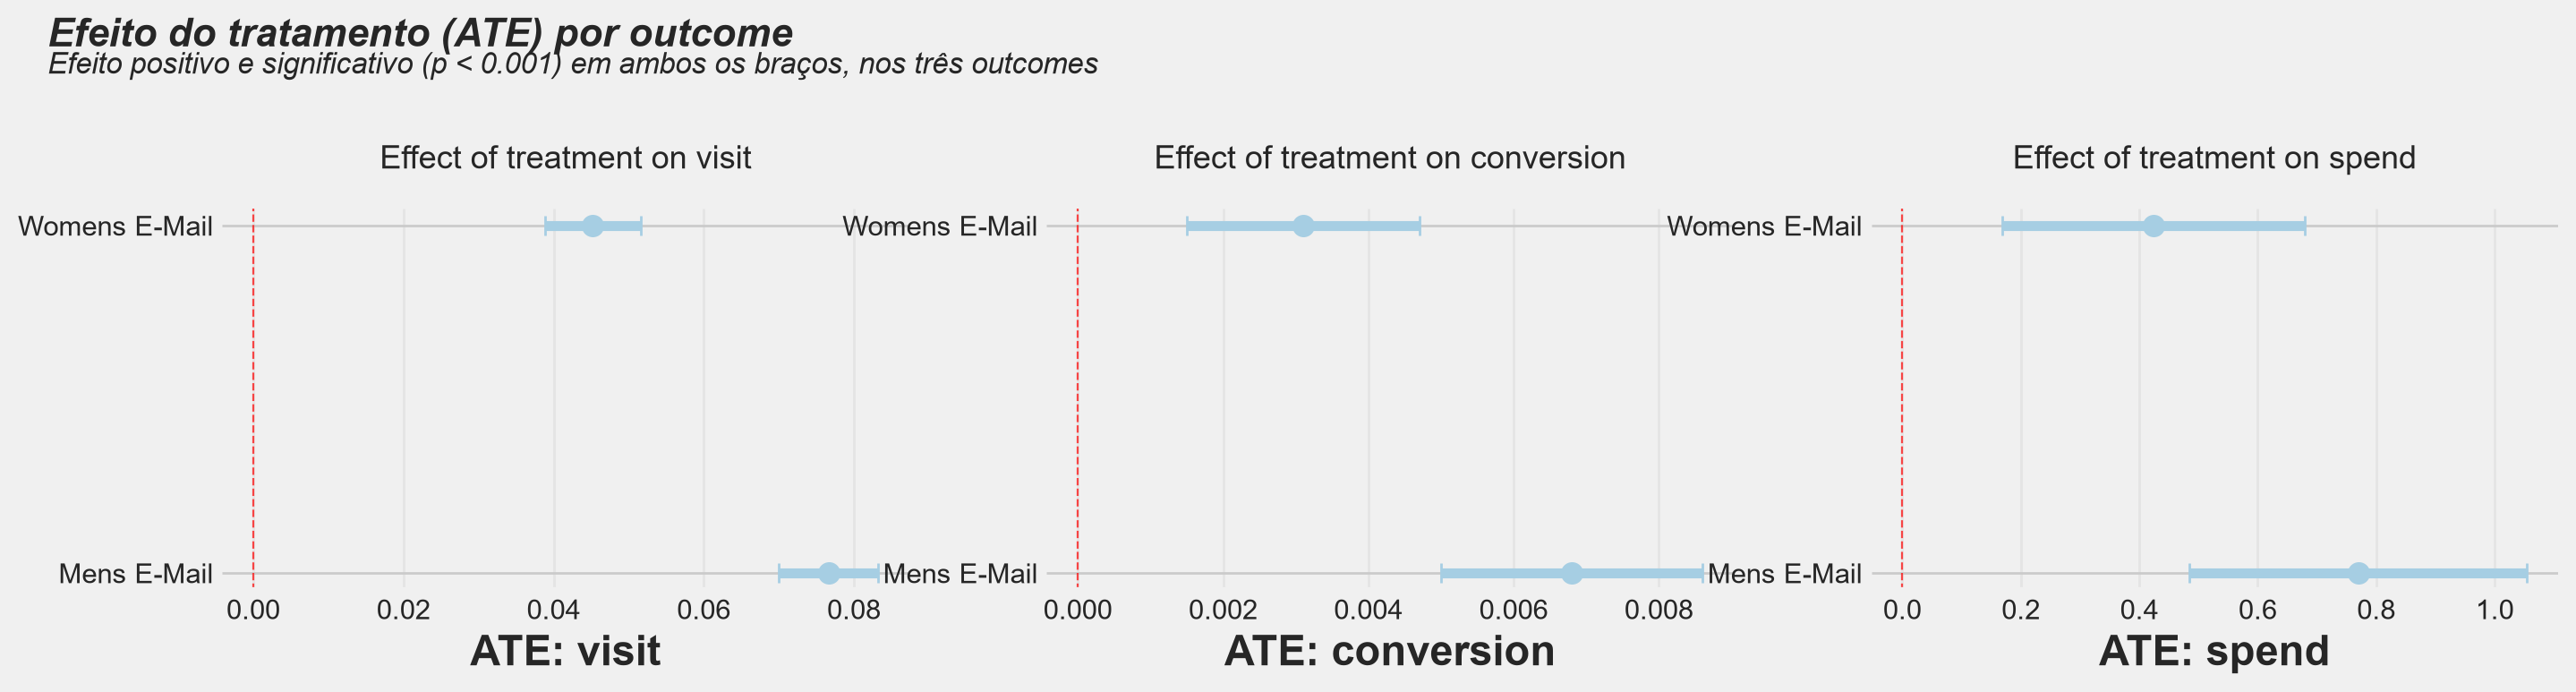

In [17]:
from src.viz import plot_ate_forest

labels = lang({
    'title': 'Efeito do tratamento (ATE) por outcome',
    'subtitle': 'Efeito positivo e significativo (p < 0.001) em ambos os braços, nos três outcomes',
})
fig, axes = plot_ate_forest(
    ate_results, outcomes=['visit', 'conversion', 'spend'],
    xlabel_prefix='ATE: ', title_prefix='Effect of treatment on ',
    title=labels['title'], subtitle=labels['subtitle'],
)
plt.show()

**Leitura dos ATEs.**

Em **todos** os outcomes e **ambos** os tratamentos, o efeito é estatisticamente significativo ($p < 0.001$) e positivo:

- **Visit (top of funnel):** Mens E-Mail empurra a taxa em +7.66pp; Womens E-Mail em +4.52pp. Diferença entre os dois tratamentos é claramente significativa (ICs não se sobrepõem).
- **Conversion (bottom of funnel):** Mens +0.68pp, Womens +0.31pp. Apesar do tamanho minúsculo, a separação dos ICs sugere que Mens E-Mail também domina aqui.
- **Spend:** Mens E-Mail gera ~\$0.77/cliente incremental; Womens ~\$0.42. Em uma base de 1M de clientes, isso é a diferença entre \$770K e \$420K em receita incremental — não desprezível.

**Observação heterogeneidade.** O fato de Mens dominar Womens *na média* não significa que Mens domina Womens *para todo cliente*. É plausível — provável até — que existam subgrupos (e.g., clientes que só compram `womens`) onde Womens E-Mail é mais efetivo. Esta é exatamente a hipótese que justifica uplift modeling: ATEs médios escondem heterogeneidade explorável.

<a id='s2-6'></a>
## 2.6 Síntese: identificação causal está garantida

Esta seção estabeleceu três coisas necessárias antes de proceder à estimação de CATE:

| Pergunta | Resposta | Evidência |
|---|---|---|
| Os braços têm tamanho comparável? | Sim, ~33% cada | $\chi^2$ contra uniforme não rejeita |
| As covariáveis estão balanceadas? | Sim, em nível excelente | Todos os \|SMD\| < 0.015; todos os testes formais com $p > 0.3$ |
| Existe sinal de tratamento? | Sim, em todos os outcomes | ATEs todos significativos a $p < 0.001$ |

**Consequência prática para as próximas seções:**
- *Unconfoundedness* é garantida por design — sem ajuste por propensity necessário.
- O CATE é identificado como $\tau(x) = E[Y \mid T=1, X=x] - E[Y \mid T=0, X=x]$ sem viés.
- Métodos da S4 (S/T/X/R-learner) e S5 (Causal Forest, Uplift Trees) estão estimando uma quantidade causal real, não um artefato confundido.

**Próximo:** [Seção 3 — baseline propensity model](#s3) (benchmark para comparação com uplift).